In [14]:
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import xarray as xr

import huracanpy

BASE_DIR = "/Users/vidale/Python_scripts/TC-TRACKS"
EXPERIMENTS = ["u-dd828"]
#EXPERIMENTS = ["u-ch330"]
YEARS = range(1980, 2014)

# Same domain dictionary as huracanpy_identify_batch_all.py - "extent" is
# [lon_min, lon_max, lat_min, lat_max], "title" is used in plot titles/suptitles.
DOMAINS = {
    "NATL": dict(
        basin="NATL", hemisphere="N", extent=[-110, 40, -5, 75],
        title="North Atlantic",
    ),
    "MED": dict(
        basin="MED", hemisphere="N", extent=[-20, 40, 20, 60],
        title="Mediterranean Sea",
    ),
    "NWPAC": dict(
        basin="WNP", hemisphere="N", extent=[-265, -135, -10, 65],
        title="Northwest Pacific",
    ),
    "SPAC": dict(
        basin="SP", hemisphere="S", extent=[140, 245, -65, 5],
        title="South Pacific",
    ),
    "EPAC": dict(
        basin="ENP", hemisphere="N", extent=[-160, -65, -5, 40],
        title="East Pacific",
    ),
    "NIO": dict(
        basin="NI", hemisphere="N", extent=[30, 100, -5, 30],
        title="North Indian Ocean",
    ),
    "SIO": dict(
        basin="SI", hemisphere="S", extent=[20, 140, -65, 5],
        title="South Indian Ocean",
    ),
    "SATL": dict(
        basin="SA", hemisphere="S", extent=[-65, 20, -50, 5],
        title="South Atlantic",
    ),
}


In [15]:
def load_domain_data(experiment, years, domain_name):
    """Load and concatenate lon/lat/nature across years for one domain.

    Returns (None, None, None) if no _TCs.nc files exist yet for this
    domain/experiment (e.g. a domain not processed by the batch script yet).
    """
    lons, lats, nats = [], [], []
    for year in years:
        in_nc = f"{BASE_DIR}/{experiment}_{year}_{domain_name}_TCs.nc"
        if not os.path.exists(in_nc):
            continue
        tracks = huracanpy.load(in_nc)
        lons.append(tracks.lon)
        lats.append(tracks.lat)
        nats.append(tracks.nature)

    if not lons:
        return None, None, None

    return (
        xr.concat(lons, dim="record"),
        xr.concat(lats, dim="record"),
        xr.concat(nats, dim="record"),
    )

In [16]:
from matplotlib.gridspec import GridSpec


def plot_domain_density(domain_name, domain, experiment, years):
    lon_all, lat_all, nat_all = load_domain_data(experiment, years, domain_name)
    if lon_all is None:
        print(f"[{domain_name}] no _TCs.nc files found, skipping")
        return

    def subset_density(mask=None):
        lon_sub = lon_all if mask is None else lon_all.isel(record=mask)
        if lon_sub.sizes.get("record", 0) == 0:
            return None
        lat_sub = lat_all if mask is None else lat_all.isel(record=mask)
        return huracanpy.calc.density(lon_sub, lat_sub, method="histogram", bin_size=3, spherical=False)

    NATURE_PANELS = [
        ("Full track", subset_density()),
        ("TC", subset_density((nat_all == "TC").values)),
        ("BC", subset_density((nat_all == "BC").values)),
        ("Tr", subset_density((nat_all == "Tr").values)),
        ("MV", subset_density((nat_all == "MV").values)),
        ("Vo", subset_density((nat_all == "Vo").values)),
        ("Ot", subset_density((nat_all == "Ot").values)),
    ]

    # Log-scaled shared colour range: a linear range washes out every nature
    # category next to "Full track" and needs re-tuning per basin/experiment
    # (values scale with number of years, domain size, etc). Log scale adapts
    # automatically and keeps low-abundance categories visible.
    vmax = max((float(D_panel.max()) for _, D_panel in NATURE_PANELS if D_panel is not None), default=0)
    if vmax <= 0:
        print(f"[{domain_name}] all-zero density, skipping plot")
        return
    vmin = vmax * 1e-2  # floor - KDE tails/sparse bins can be near-zero, so
                         # without a floor the scale gets dominated by noise
                         # instead of the real structure
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 20)
    norm = LogNorm(vmin=vmin, vmax=vmax, clip=False)

    cmap = plt.get_cmap("terrain_r").copy()
    cmap.set_under("white")  # anything below the floor reads as "negligible"

    extent = domain["extent"]
    central_longitude = 0.5 * (extent[0] + extent[1])
    domain_crs = ccrs.PlateCarree(central_longitude=central_longitude)
    map_aspect = (extent[1] - extent[0]) / (extent[3] - extent[2])

    # "Full track" spans all 3 columns of the top row and that row is given
    # height_ratio 3 (vs 1 for each row below) - since it's 3x wider AND 3x
    # taller than a single small panel, its aspect ratio ends up identical to
    # a small panel's, so both fit their box with ~zero letterboxing for any
    # domain shape, rather than needing per-domain tuning.
    col_width = 4.2
    row_height = col_width / map_aspect
    fig_width = 3 * col_width + 2.3   # + room for the shared colorbar
    fig_height = 5 * row_height + 0.6  # + room for the suptitle

    fig = plt.figure(figsize=(fig_width, fig_height), layout="constrained")
    gs = GridSpec(3, 3, figure=fig, height_ratios=[3, 1, 1])
    ax_big = fig.add_subplot(gs[0, :], projection=domain_crs)
    axes_small = [
        fig.add_subplot(gs[1, 0], projection=domain_crs),
        fig.add_subplot(gs[1, 1], projection=domain_crs),
        fig.add_subplot(gs[1, 2], projection=domain_crs),
        fig.add_subplot(gs[2, 0], projection=domain_crs),
        fig.add_subplot(gs[2, 1], projection=domain_crs),
        fig.add_subplot(gs[2, 2], projection=domain_crs),
    ]

    mesh = None
    for ax, (title, D_panel) in zip([ax_big] + axes_small, NATURE_PANELS):
        # direct xlim/ylim instead of ax.set_extent() - set_extent() silently
        # falls back to a full-globe view for domains whose extent crosses
        # +/-180 (e.g. SPAC), which also breaks the title's position calc
        ax.set_xlim(extent[0] - central_longitude, extent[1] - central_longitude)
        ax.set_ylim(extent[2], extent[3])
        ax.coastlines()
        if D_panel is None:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center", fontsize=9, color="0.5")
        else:
            mesh = D_panel.plot(
                ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, norm=norm, add_colorbar=False,
            )
        ax.set_title(title)  # must come after .plot() - xarray's plot() clears any pre-existing title

    # one shared colorbar for the whole figure instead of one per panel
    fig.colorbar(mesh, ax=[ax_big] + axes_small, shrink=0.6, pad=0.02, label="TC Track Density (log scale)")

    fig.suptitle(f"{domain['title']} TC Track Density for {experiment} ({years.start}-{years.stop - 1})")
    fig.savefig(f"{BASE_DIR}/density_{experiment}_{years.start}-{years.stop - 1}_{domain_name}_MultiNature.png", dpi=300)
    plt.show()

/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracan

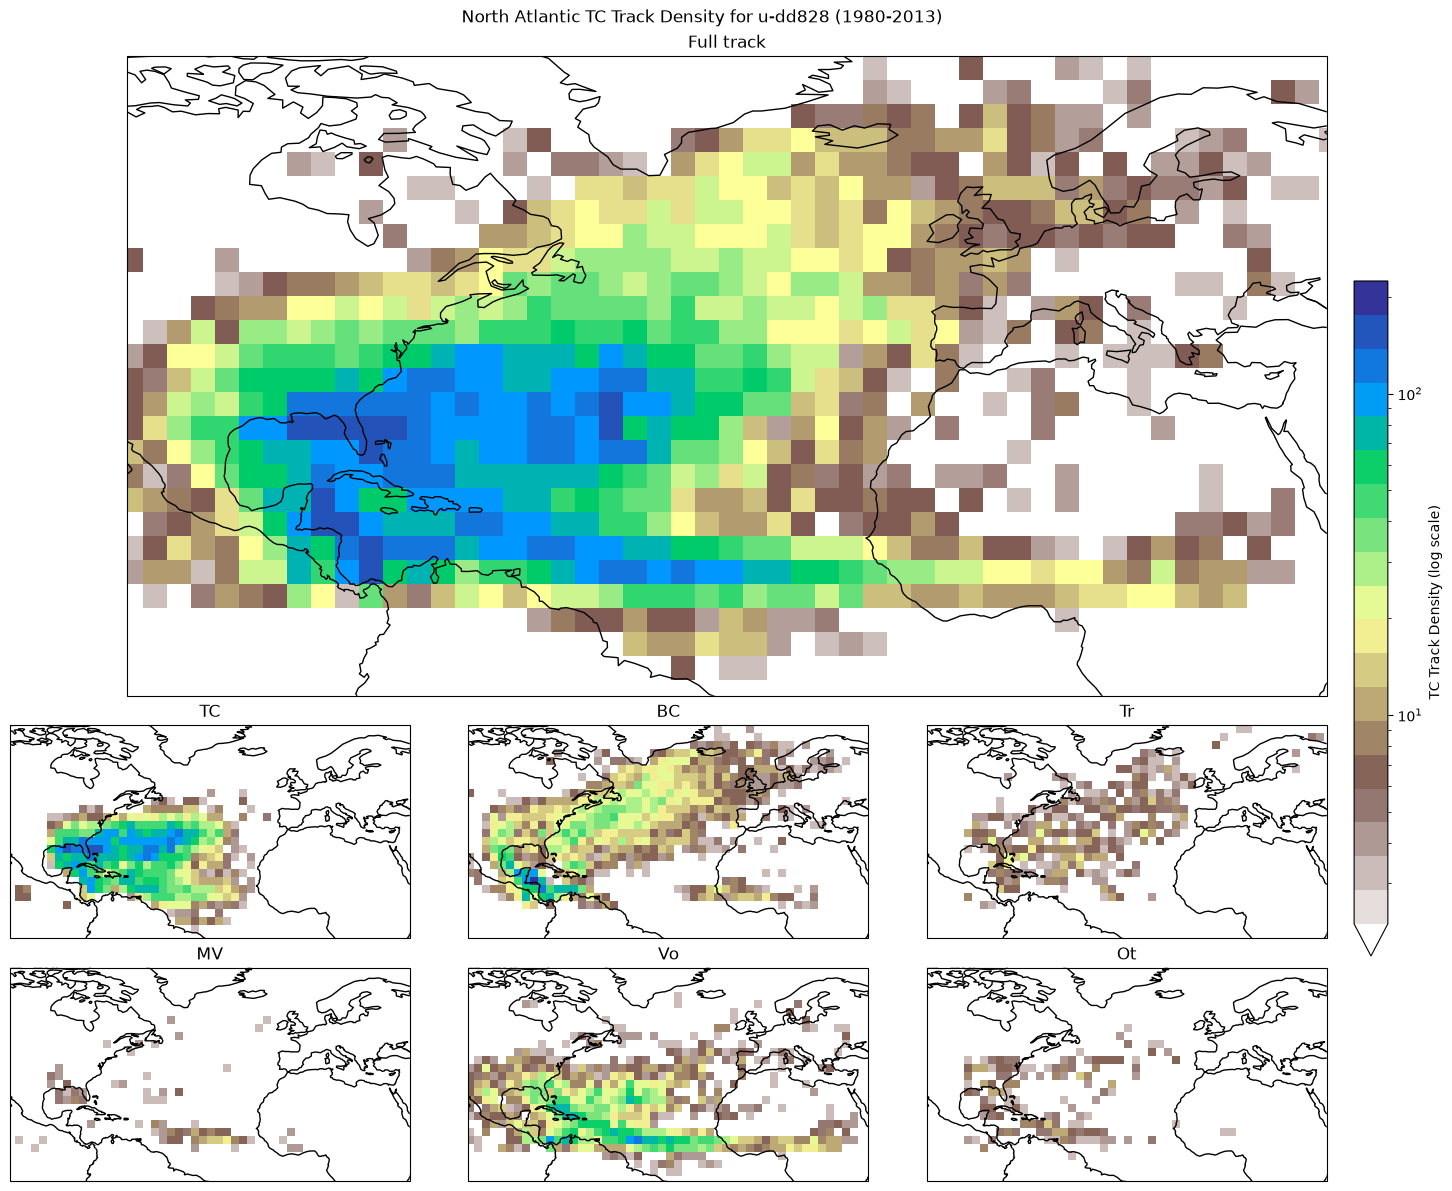

/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracan

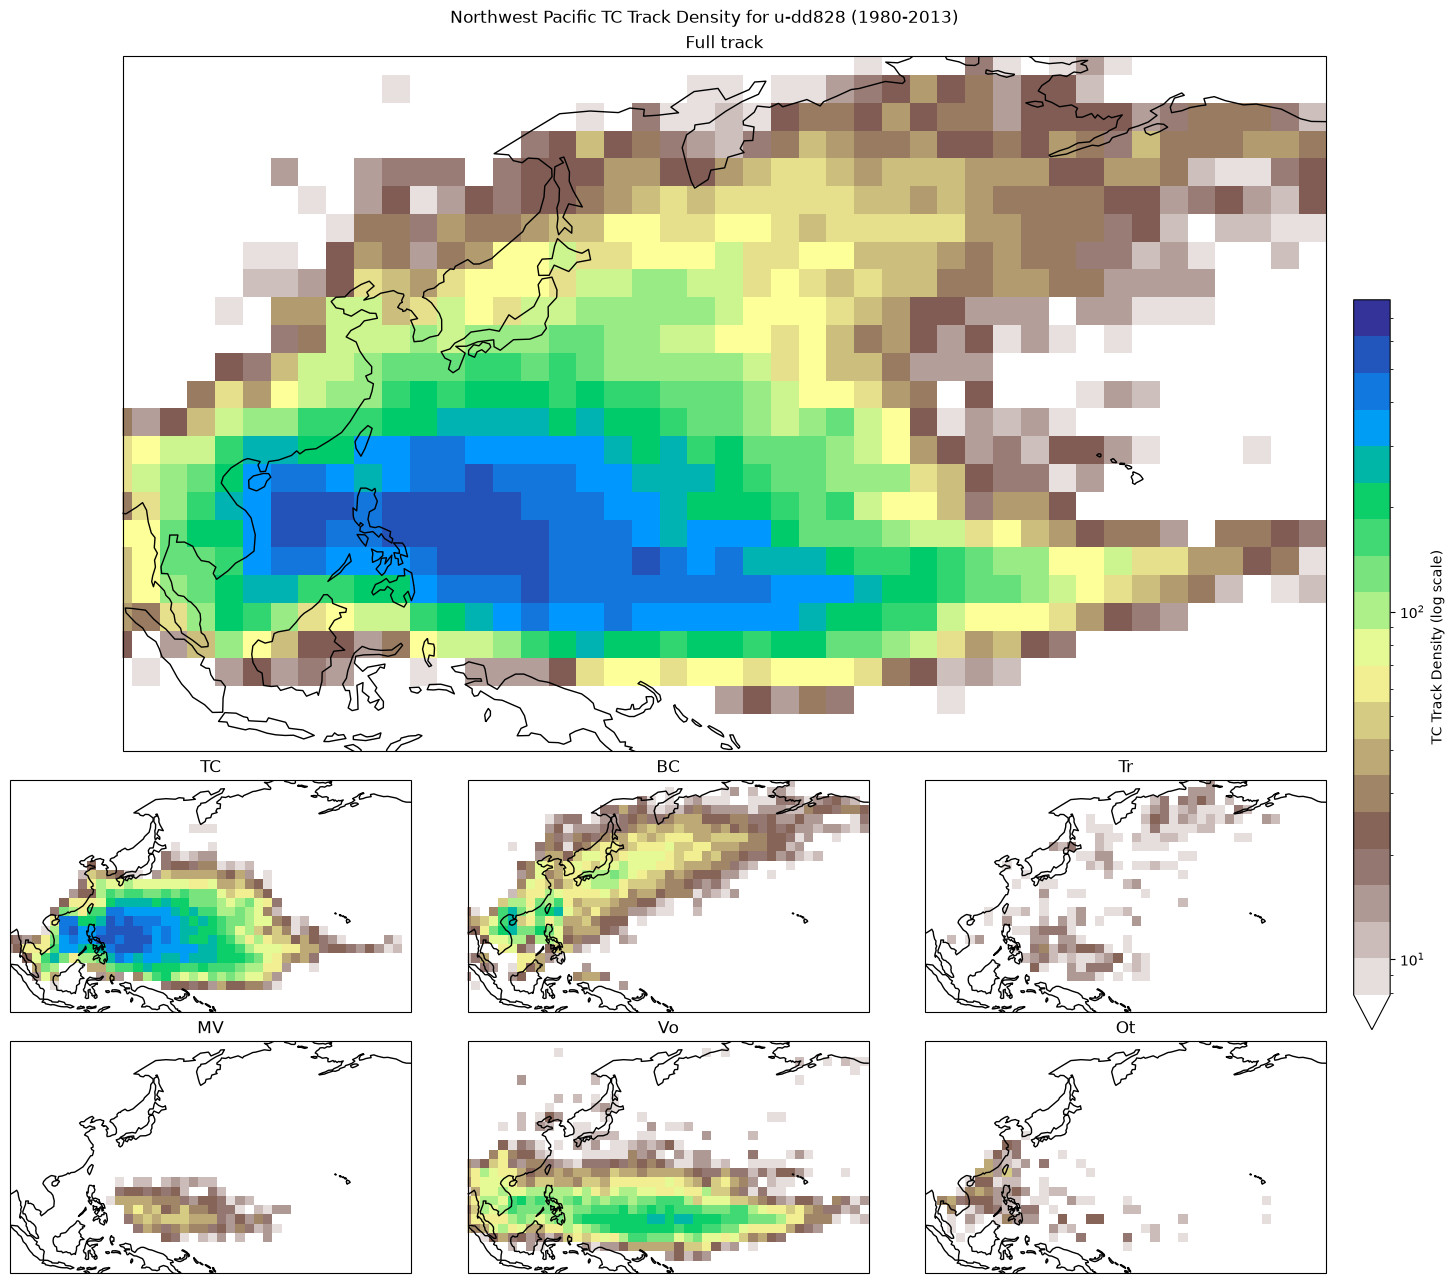

/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracan

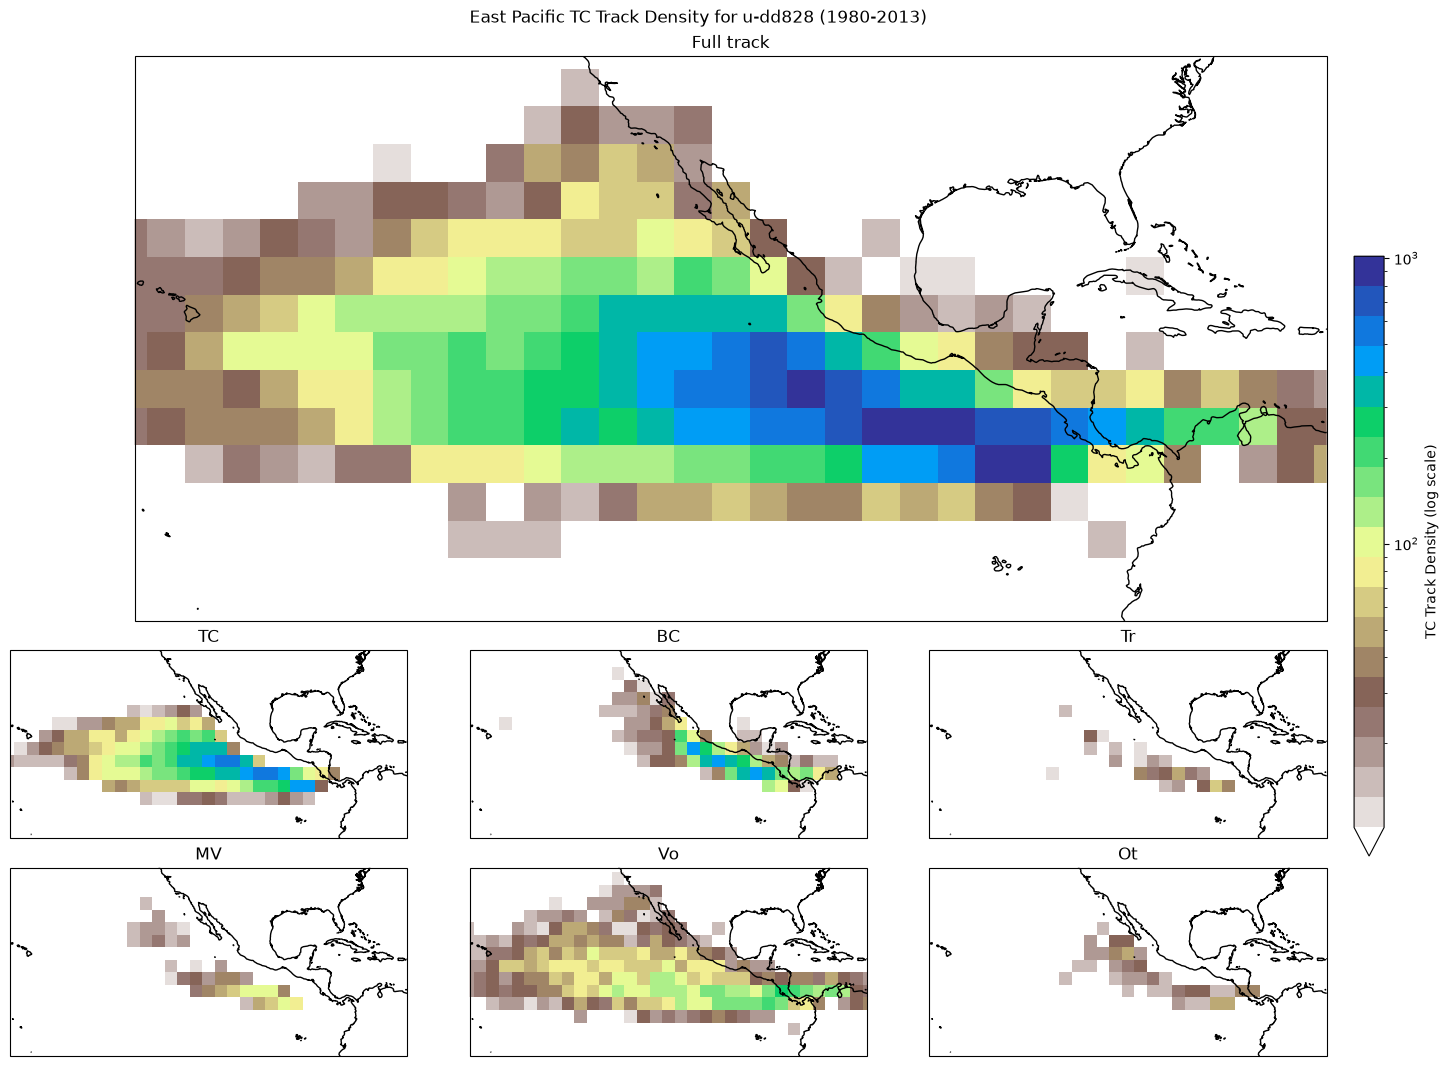

/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracanpy/calc/_density.py:88: UserWarning: By default density does not take into account the spherical geometry ofthe Earth. Set spherical=True to account for this
  warnings.warn(
/Users/vidale/anaconda3/lib/python3.14/site-packages/huracan

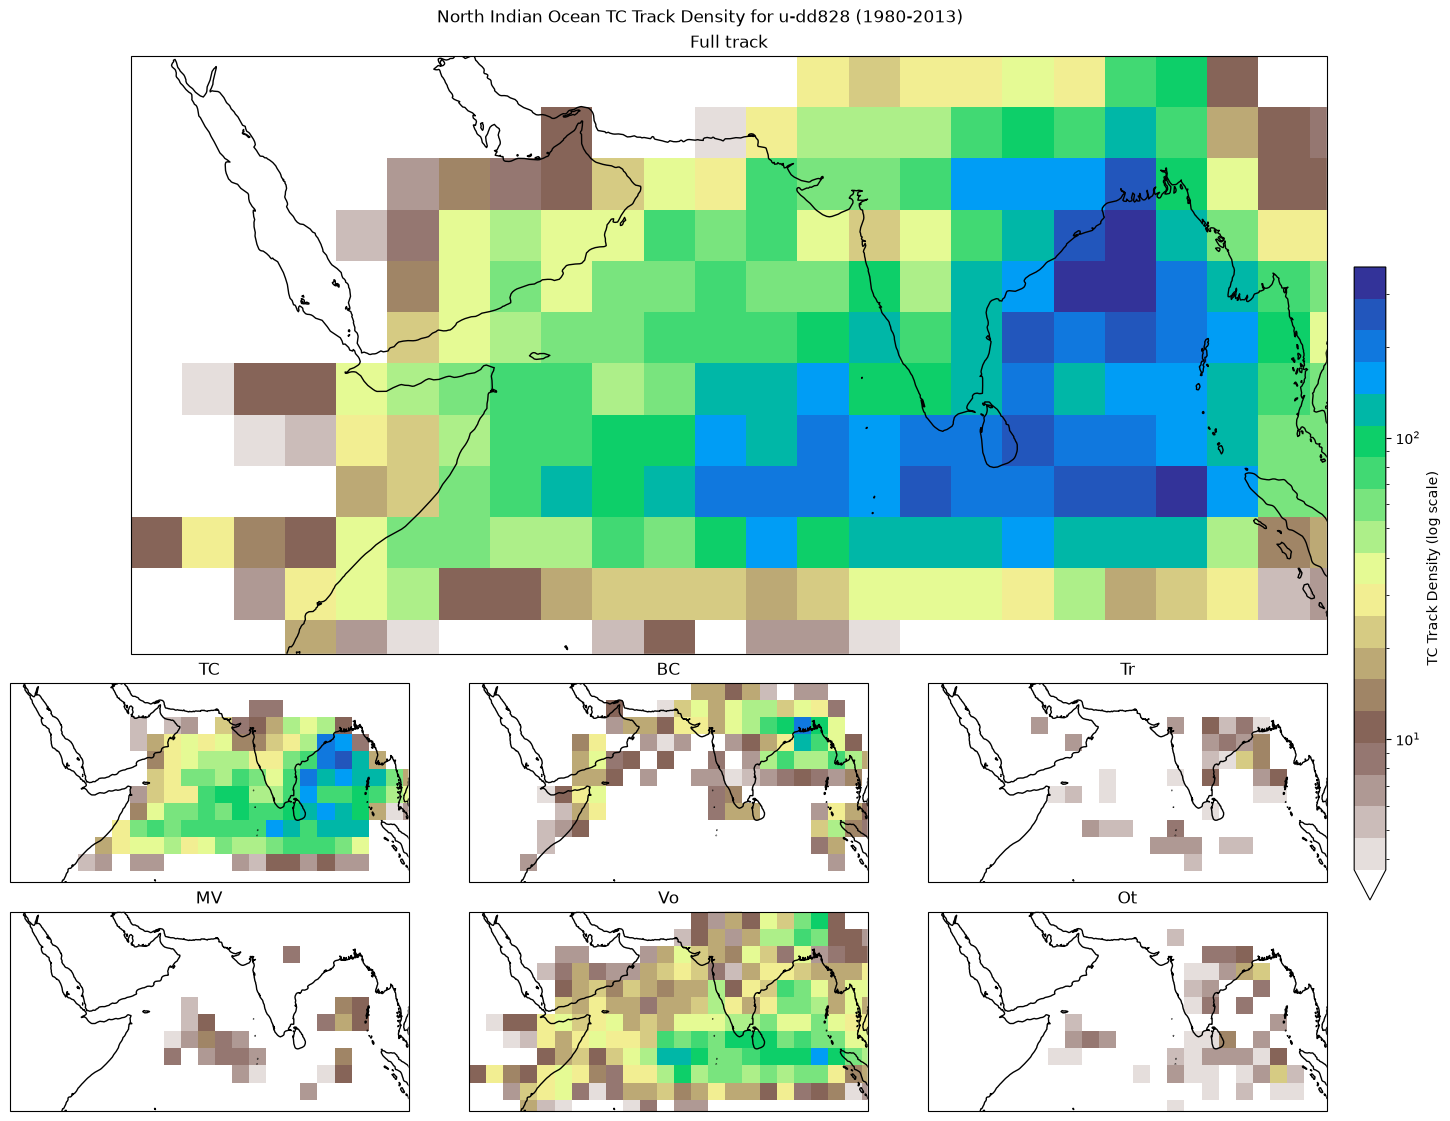

In [ ]:
#SKIP_DOMAINS = {"MED","SPAC","SIO", "SATL"}  # too sparse to be useful yet - storms in only 1-2 of 34 years
SKIP_DOMAINS = {"MED"} 

for experiment in EXPERIMENTS:
    for domain_name, domain in DOMAINS.items():
        if domain_name in SKIP_DOMAINS:
            continue
        plot_domain_density(domain_name, domain, experiment, YEARS)